# import

In [53]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns

import my_module as my


from statsmodels.tsa.seasonal import seasonal_decompose

# Tests & Models
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

from sklearn.model_selection import cross_val_score
from statsmodels.tsa.ar_model import AutoReg, AutoRegResults

from sklearn.metrics import mean_squared_error, accuracy_score


from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX

# Misc
from sklearn.model_selection import TimeSeriesSplit
from itertools import product

***
# 0. Leitura e processamento inicial de dados

In [54]:
df = pd.read_csv('data/dados.csv', index_col='Data')
df.head()

,Último,Abertura,Máxima,Mínima,Vol.,Var%
Data,,,,,,
30.06.2025,138.855,136.865,139.103,136.430,"7,68M","1,45%"
27.06.2025,136.866,137.113,137.209,136.469,"6,24B","-0,18%"
26.06.2025,137.114,135.767,137.353,135.756,"8,02B","0,99%"
25.06.2025,135.767,137.163,137.163,135.565,"7,71B","-1,02%"
24.06.2025,137.165,136.552,138.156,136.254,"8,08B","0,45%"


In [55]:
col_dict = my.format_columns(df)
df.head()

,ultimo,abertura,maxima,minima,vol,var
Data,,,,,,
30.06.2025,138.855,136.865,139.103,136.430,"7,68M","1,45%"
27.06.2025,136.866,137.113,137.209,136.469,"6,24B","-0,18%"
26.06.2025,137.114,135.767,137.353,135.756,"8,02B","0,99%"
25.06.2025,135.767,137.163,137.163,135.565,"7,71B","-1,02%"
24.06.2025,137.165,136.552,138.156,136.254,"8,08B","0,45%"


In [56]:
df.dtypes

ultimo      float64
abertura    float64
maxima      float64
minima      float64
vol          object
var          object
dtype: object

## Tratamento e formatação de valores

In [57]:
# Formatacao e nomeacao do index
df.index = pd.to_datetime(df.index, dayfirst=True)
df.index = df.index.rename('data')
col_dict ['data'] = 'Data'
df.head()

,ultimo,abertura,maxima,minima,vol,var
data,,,,,,
2025-06-30,138.855,136.865,139.103,136.430,"7,68M","1,45%"
2025-06-27,136.866,137.113,137.209,136.469,"6,24B","-0,18%"
2025-06-26,137.114,135.767,137.353,135.756,"8,02B","0,99%"
2025-06-25,135.767,137.163,137.163,135.565,"7,71B","-1,02%"
2025-06-24,137.165,136.552,138.156,136.254,"8,08B","0,45%"


In [58]:
# Tornando 'var' em numero
df['var'] = df['var'].replace('%','',regex=True).replace(',','.',regex=True)
df['var'] = df['var'].astype(float)
df.head()

,ultimo,abertura,maxima,minima,vol,var
data,,,,,,
2025-06-30,138.855,136.865,139.103,136.430,"7,68M",1.45
2025-06-27,136.866,137.113,137.209,136.469,"6,24B",-0.18
2025-06-26,137.114,135.767,137.353,135.756,"8,02B",0.99
2025-06-25,135.767,137.163,137.163,135.565,"7,71B",-1.02
2025-06-24,137.165,136.552,138.156,136.254,"8,08B",0.45


In [59]:
# Ordenando nosso index
df = df.sort_index()
df.head()

,ultimo,abertura,maxima,minima,vol,var
data,,,,,,
2010-01-29,65.402,65.591,66.576,65.140,"1,82M",-0.28
2010-02-01,66.572,65.402,66.763,65.362,"1,49M",1.79
2010-02-02,67.163,66.589,67.321,66.539,"1,59M",0.89
2010-02-03,67.109,67.163,67.347,66.774,"1,76M",-0.08
2010-02-04,63.934,67.100,67.100,63.750,"2,26M",-4.73


In [60]:
# Retirando colunas irrelevantes
df = df.drop(['maxima','minima', 'abertura', 'var', 'vol'], axis=1)
df.head()

,ultimo
data,
2010-01-29,65.402
2010-02-01,66.572
2010-02-02,67.163
2010-02-03,67.109
2010-02-04,63.934


## Determinando frequência
Nossa time series não inclui fins de semana e feriados. Vamos adicioná-los para deixá-la contínua.

In [61]:
df = df.asfreq('d')
df['dia_semana'] = df.index.day_name()
col_dict['dia_semana'] = 'Dia da semana'
df.head()

,ultimo,dia_semana
data,,
2010-01-29,65.402,Friday
2010-01-30,NaN,Saturday
2010-01-31,NaN,Sunday
2010-02-01,66.572,Monday
2010-02-02,67.163,Tuesday


In [62]:
df['dia_util'] = np.nan
for i in df.index:
    df.loc[i, 'dia_util'] = False if pd.isna(df.loc[i, 'ultimo']) else True
df.head()

D:\Temp\ipykernel_75856\4174846468.py:3: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'True' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df.loc[i, 'dia_util'] = False if pd.isna(df.loc[i, 'ultimo']) else True


,ultimo,dia_semana,dia_util
data,,,
2010-01-29,65.402,Friday,True
2010-01-30,NaN,Saturday,False
2010-01-31,NaN,Sunday,False
2010-02-01,66.572,Monday,True
2010-02-02,67.163,Tuesday,True


In [63]:
df = df.ffill()
df.head()

D:\Temp\ipykernel_75856\3655253257.py:1: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df = df.ffill()


,ultimo,dia_semana,dia_util
data,,,
2010-01-29,65.402,Friday,True
2010-01-30,65.402,Saturday,False
2010-01-31,65.402,Sunday,False
2010-02-01,66.572,Monday,True
2010-02-02,67.163,Tuesday,True


# 1. Análise inicial

In [64]:
sns.set_style('darkgrid')

In [65]:
col = 'ultimo'

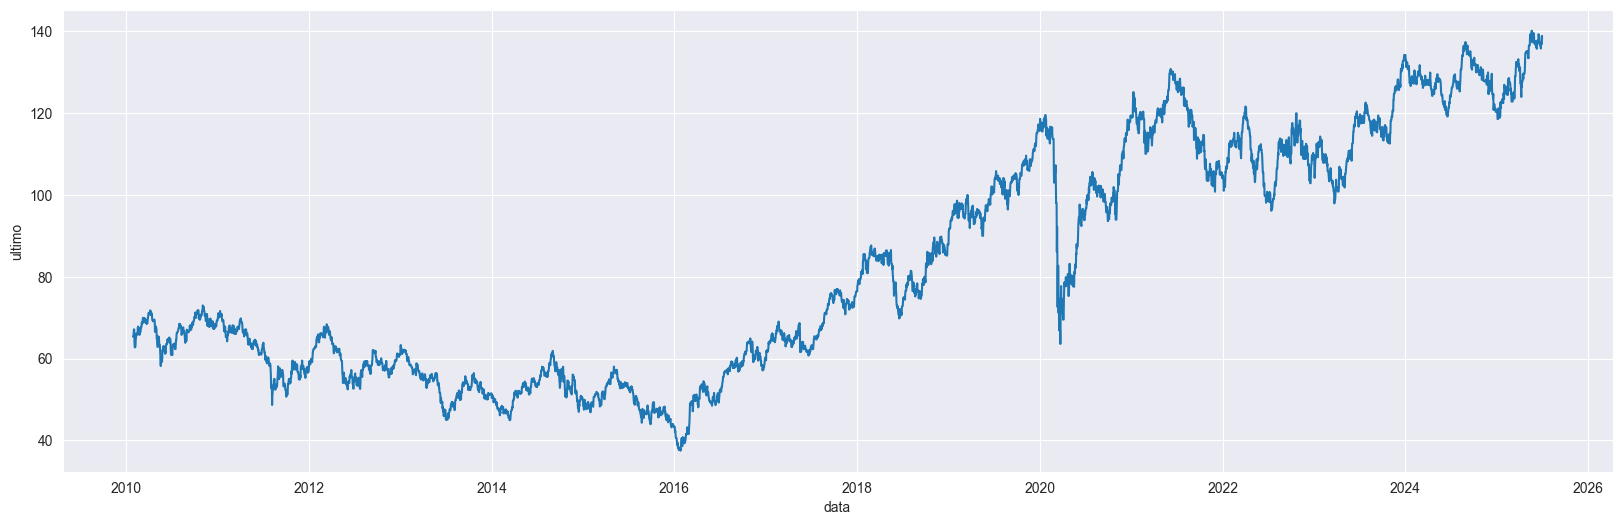

In [66]:
fig = plt.figure(figsize=(20,6))
sns.lineplot(
    df[col]
);

## Dados originais

### seasonal_decompose
Apenas do ano de 2023

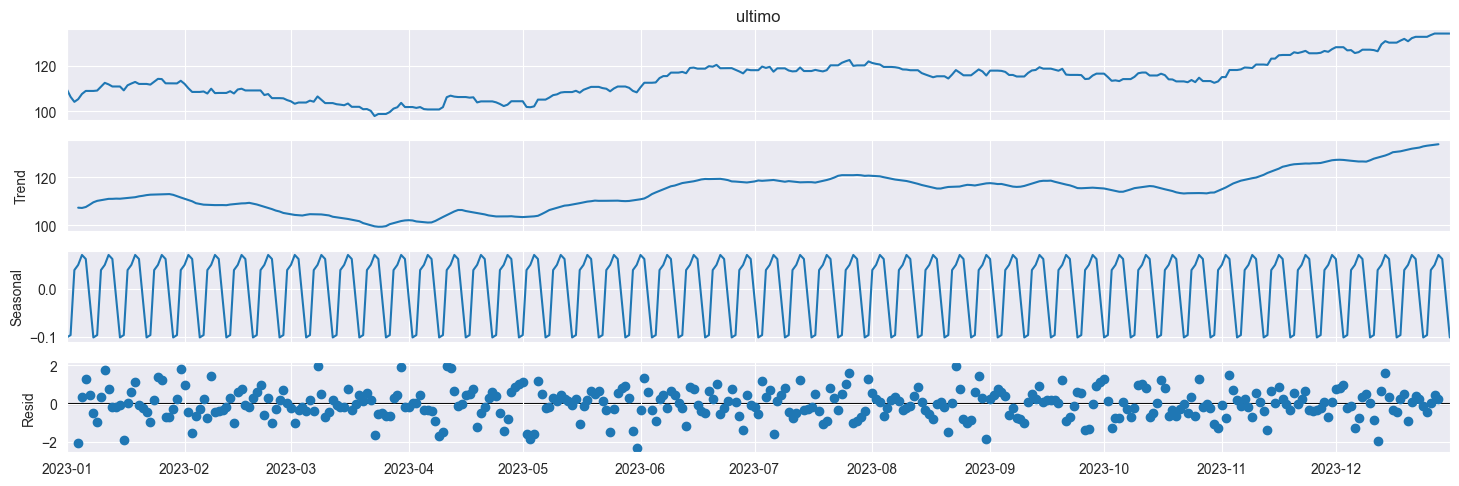

In [67]:
year = 2023
mask = ((df.index > f'{year-1}-12-31') & (df.index < f'{year+1}-01-01'))
fig = seasonal_decompose(
    df[col].loc[mask],
    model = 'additive'
).plot();

fig.set_size_inches(16, 5)

### ACF & PACF

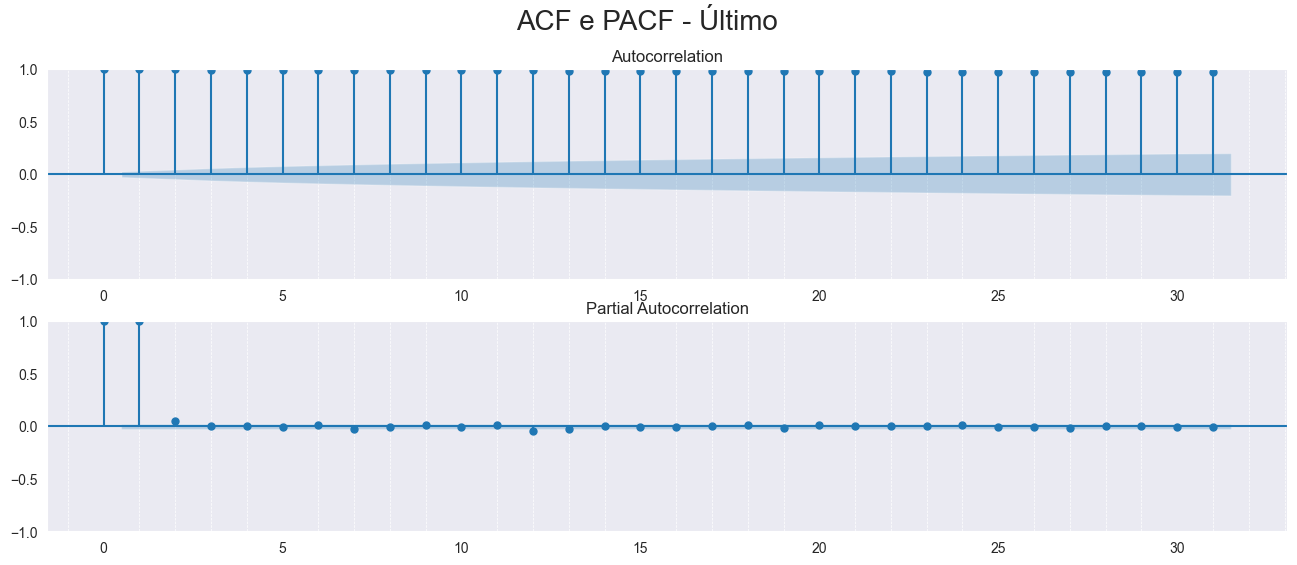

In [68]:
lags = 31*1

fig, axs = plt.subplots(
    nrows = 2,
    ncols = 1,
    figsize = (16, 6)
)

fig.suptitle(
    f'ACF e PACF - {col_dict[col]}',
    fontsize = 20
)

ax = axs[0]
plot_acf(
    df[col],
    ax = ax,
    lags = lags
)
ax.xaxis.set_minor_locator(ticker.MultipleLocator(1,1))
ax.set_axisbelow(True)
ax.grid(
    which = 'major'
)
ax.grid(
    which = 'minor',
    linestyle = '--',
    linewidth = 0.5
)


ax = axs[1]
plot_pacf(
    df[col],
    ax = ax,
    lags = lags
)
ax.xaxis.set_minor_locator(ticker.MultipleLocator(1,1))
ax.set_axisbelow(True)
ax.grid(
    which = 'major'
)
ax.grid(
    which = 'minor',
    linestyle = '--',
    linewidth = 0.5
)

plt.show()


> ## O alto ACF quase indica uma série não-estacionária.

### Teste KPSS e ADF

In [69]:
def stationary(df : pd.DataFrame, significance : float = 0.05):
    adf = adfuller(df)
    adf_p = adf[1]
    print('ADF')
    print(f'p\t\t{adf_p:10f}')

    if adf_p > significance:
        print(f'NON REJECTION\tA série NÃO é estacionária')
    else:
        print(f'REJECTION\tA série é estacionária')

    kpss_result = kpss(df)
    kpss_p = kpss_result[1]

    print(f'\nKPSS')
    print(f'p\t\t{kpss_p:10f}')

    if kpss_p > significance:
        print(f'NON REJECTION\tA série é estacionária')
    else:
        print(f'REJECTION\tA série NÃO é estacionária')


    return adf, kpss_result

In [70]:
stationary(df[col]);

ADF
p		  0.833330
NON REJECTION	A série NÃO é estacionária

KPSS
p		  0.010000
REJECTION	A série NÃO é estacionária


D:\Temp\ipykernel_75856\3463684406.py:12: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_result = kpss(df)


## Removendo tendência

In [71]:
def make_stationary(data : pd.Series(), significance : float = 0.05, max : int = 10):
    result = False
    count = 0

    while (count <= max) and (not result):
        count += 1

        diff = data.diff(count)    

        adf = adfuller(diff[count:])
        adf_p = adf[1]

        kpss_result = kpss(diff[count:])
        kpss_p = kpss_result[1]
        result = (adf_p < significance) and (kpss_p > significance)

    return count, data.diff(count)

In [72]:
count, df[f'{col}_diff{count}'] = make_stationary(df[col])
col_dict[f'{col}_diff{count}'] = f'{col_dict[col]} - Diferenciado x{count}'

D:\Temp\ipykernel_75856\2019883017.py:13: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_result = kpss(diff[count:])


### Teste KPSS e ADF

In [73]:
stationary(df[f'{col}_diff{count}'].iloc[count:]);

ADF
p		  0.000000
REJECTION	A série é estacionária

KPSS
p		  0.100000
NON REJECTION	A série é estacionária


D:\Temp\ipykernel_75856\3463684406.py:12: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_result = kpss(df)


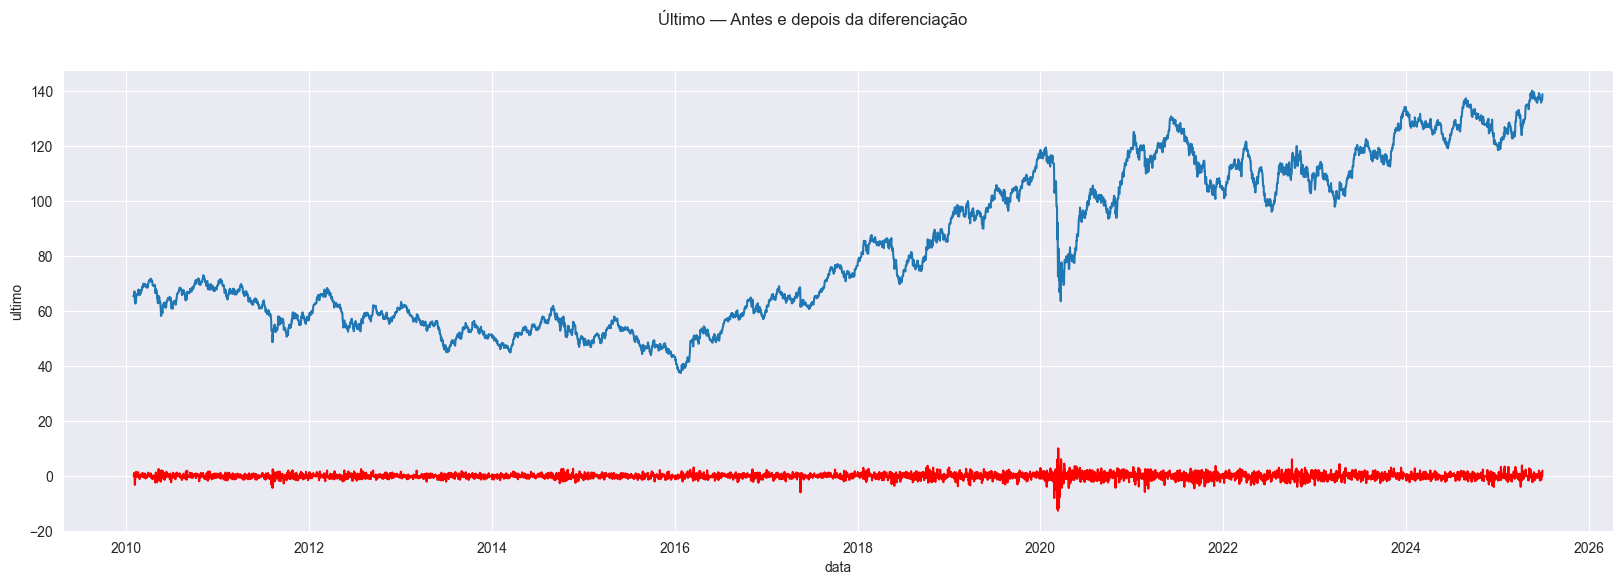

In [74]:
fig = plt.figure(figsize=(20,6))

fig.suptitle(f'{col_dict[col]} — Antes e depois da diferenciação')

sns.lineplot(
    df[f'{col}']
)

sns.lineplot(
    df[f'{col}_diff{count}'],
    color = 'red'
);

### ACF & PACF

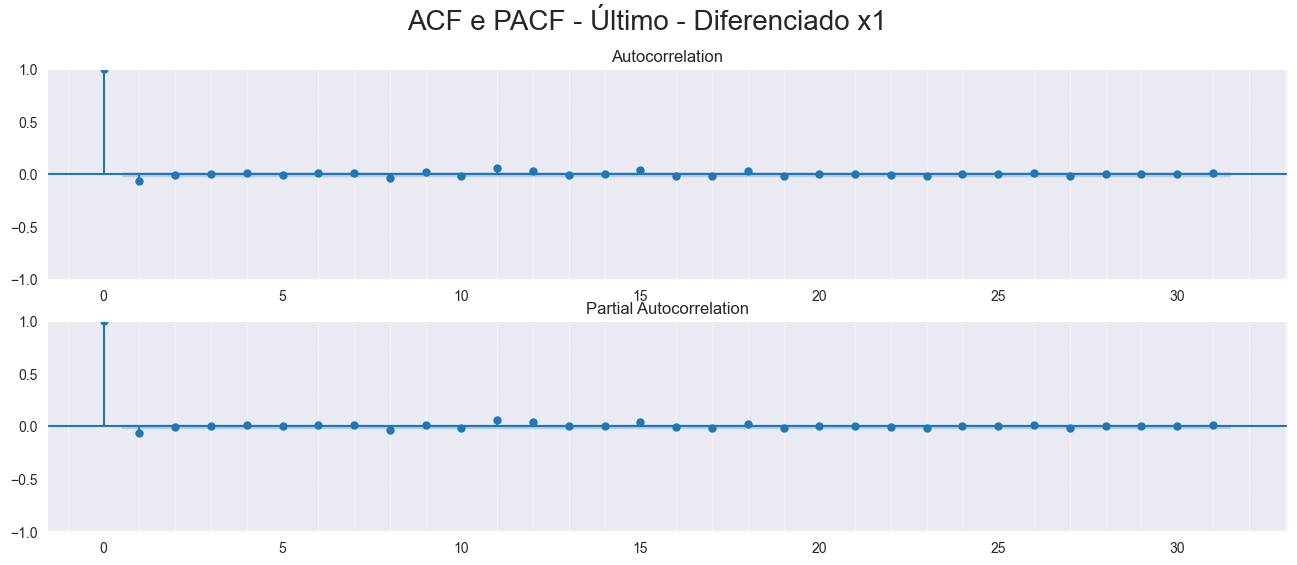

In [75]:
lags = 31

col = f'{col}_diff{count}'

fig, axs = plt.subplots(
    nrows = 2,
    ncols = 1,
    figsize = (16, 6)
)

fig.suptitle(
    f'ACF e PACF - {col_dict[col]}',
    fontsize = 20
)

ax = axs[0]
plot_acf(
    df[col].iloc[count:],
    ax = ax,
    lags = lags
)
ax.xaxis.set_minor_locator(ticker.MultipleLocator(1,1))
ax.set_axisbelow(True)
ax.grid(
    which = 'major'
)
ax.grid(
    which = 'minor',
    linestyle = '--',
    linewidth = 0.5
)


ax = axs[1]
plot_pacf(
    df[col].iloc[count:],
    ax = ax,
    lags = lags
)
ax.xaxis.set_minor_locator(ticker.MultipleLocator(1,1))
ax.set_axisbelow(True)
ax.grid(
    which = 'major'
)
ax.grid(
    which = 'minor',
    linestyle = '--',
    linewidth = 0.5
)

plt.show()


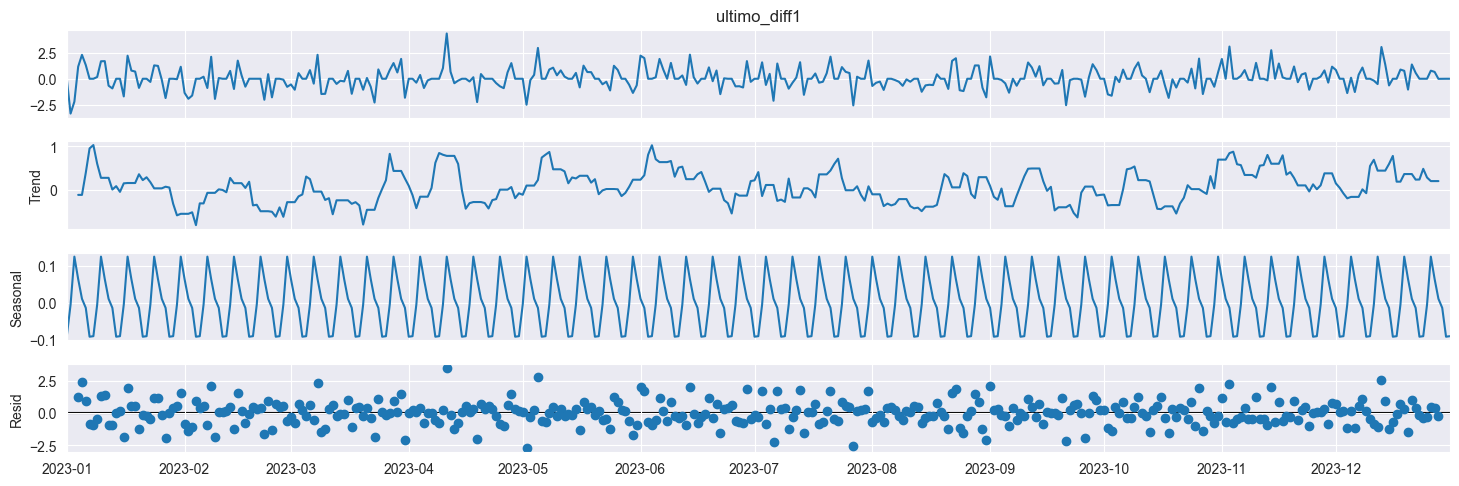

In [76]:
year = 2023
mask = ((df.index[count:] > f'{year-1}-12-31') & (df.index[count:] < f'{year+1}-01-01'))
# fig = seasonal_decompose(
#     df[col].loc[mask],
#     model = 'additive'
# ).plot();
fig = seasonal_decompose(
    df[col].iloc[count:].loc[mask]
    ).plot()


fig.set_size_inches(16, 5)


## Removendo sazonalidade
Temos uma sazonalidade semanal, portanto faremos a diferenciação de 7 dias

In [77]:
count = 7
df['ultimo_diff7'] = df['ultimo'].diff(count)

df.head()

,ultimo,dia_semana,dia_util,ultimo_diff1,ultimo_diff7
data,,,,,
2010-01-29,65.402,Friday,True,NaN,NaN
2010-01-30,65.402,Saturday,False,0.000,NaN
2010-01-31,65.402,Sunday,False,0.000,NaN
2010-02-01,66.572,Monday,True,1.170,NaN
2010-02-02,67.163,Tuesday,True,0.591,NaN


In [78]:
col_dict['ultimo_diff7'] = 'Último - Diferenciado x7'

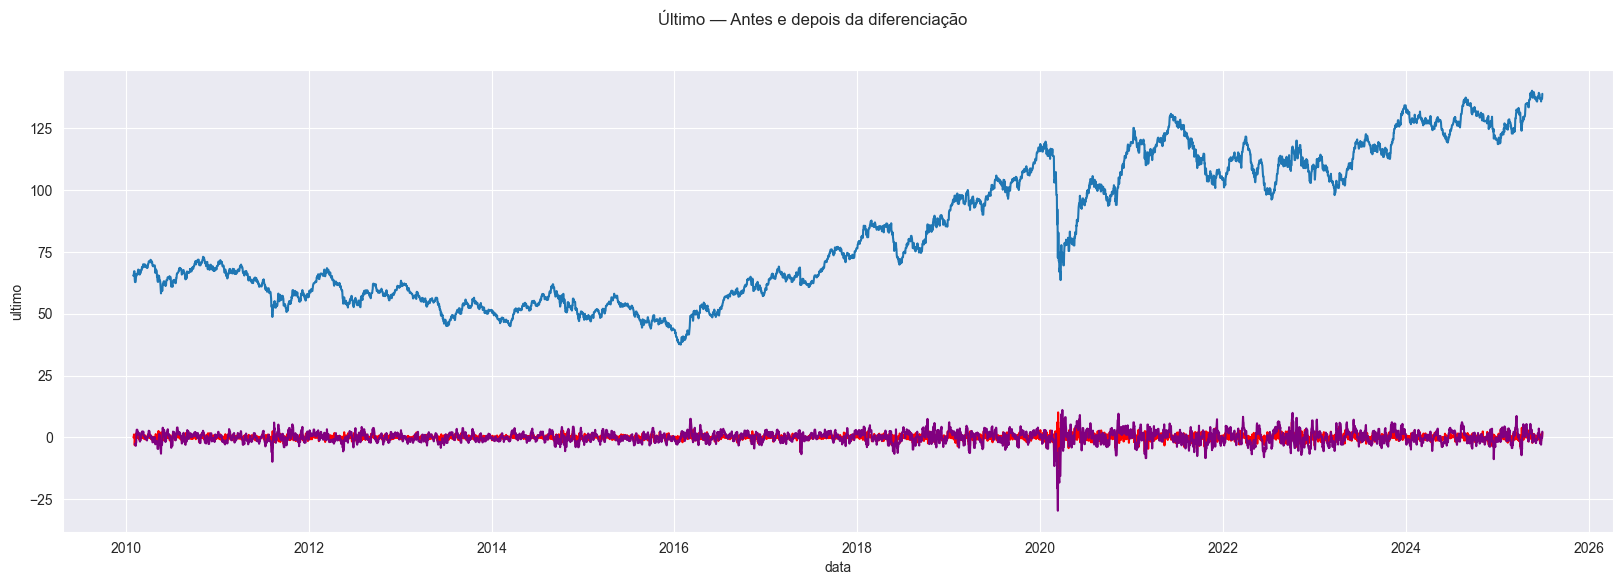

In [79]:
col = 'ultimo'
fig = plt.figure(figsize=(20,6))

fig.suptitle(f'{col_dict[col]} — Antes e depois da diferenciação')

sns.lineplot(
    df[f'{col}']
)

sns.lineplot(
    df[f'{col}_diff1'],
    color = 'red'
);

sns.lineplot(
    df[f'{col}_diff7'],
    color = 'purple'
);

### ACF e PACF

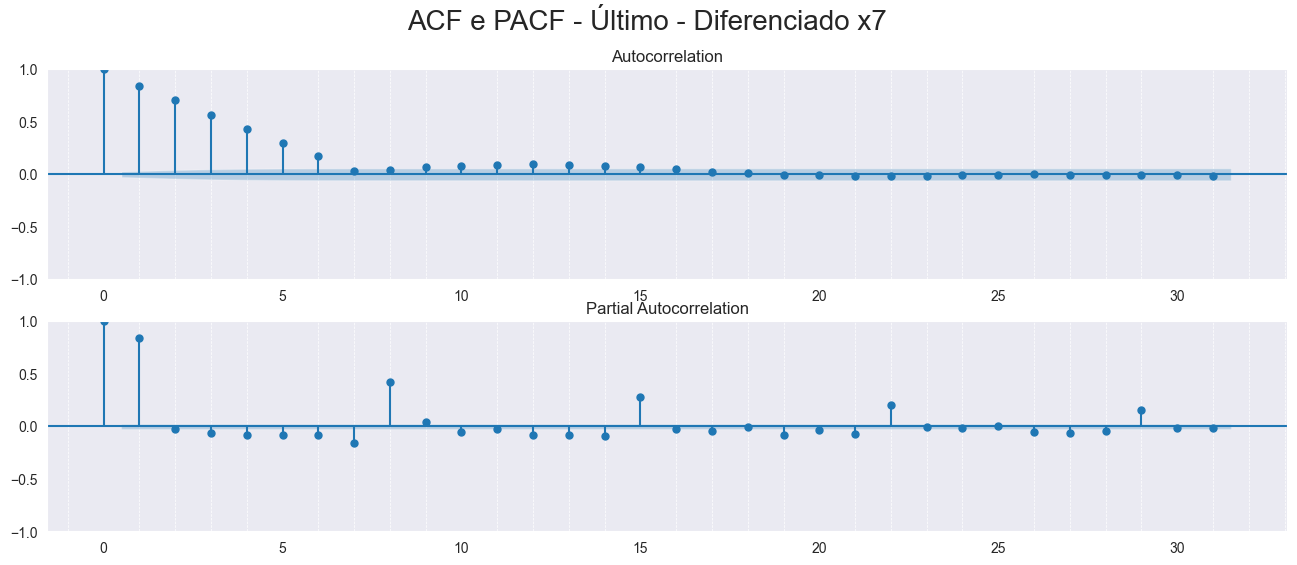

In [80]:
lags = 31

col = f'{col}_diff{count}'

fig, axs = plt.subplots(
    nrows = 2,
    ncols = 1,
    figsize = (16, 6)
)

fig.suptitle(
    f'ACF e PACF - {col_dict[col]}',
    fontsize = 20
)

ax = axs[0]
plot_acf(
    df[col].iloc[count:],
    ax = ax,
    lags = lags
)
ax.xaxis.set_minor_locator(ticker.MultipleLocator(1,1))
ax.set_axisbelow(True)
ax.grid(
    which = 'major'
)
ax.grid(
    which = 'minor',
    linestyle = '--',
    linewidth = 0.5
)


ax = axs[1]
plot_pacf(
    df[col].iloc[count:],
    ax = ax,
    lags = lags
)
ax.xaxis.set_minor_locator(ticker.MultipleLocator(1,1))
ax.set_axisbelow(True)
ax.grid(
    which = 'major'
)
ax.grid(
    which = 'minor',
    linestyle = '--',
    linewidth = 0.5
)

plt.show()


### Teste KPSS e ADF


In [81]:
stationary(df['ultimo_diff7'].iloc[count:]);

ADF
p		  0.000000
REJECTION	A série é estacionária

KPSS
p		  0.100000
NON REJECTION	A série é estacionária


D:\Temp\ipykernel_75856\3463684406.py:12: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_result = kpss(df)


***
# 2. Encontrando um modelo

Como temos uma **time-series** que **não é estacionária** e **possue sazonalidade**, utilizaremos o modelo `SARIMA`.

## Extração de parâmetros


Vamos agora colocar nossos gráficos ADF e PACFs juntos, para extrair nossos parâmetros.

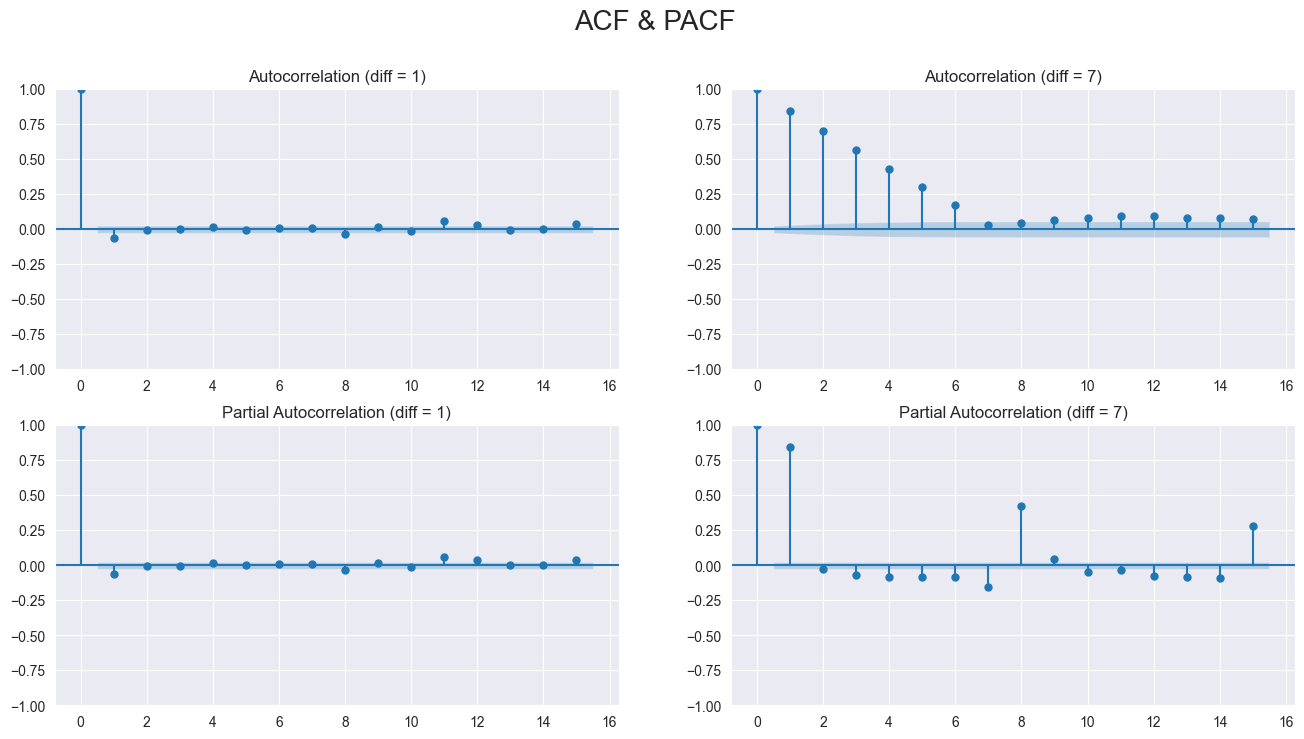

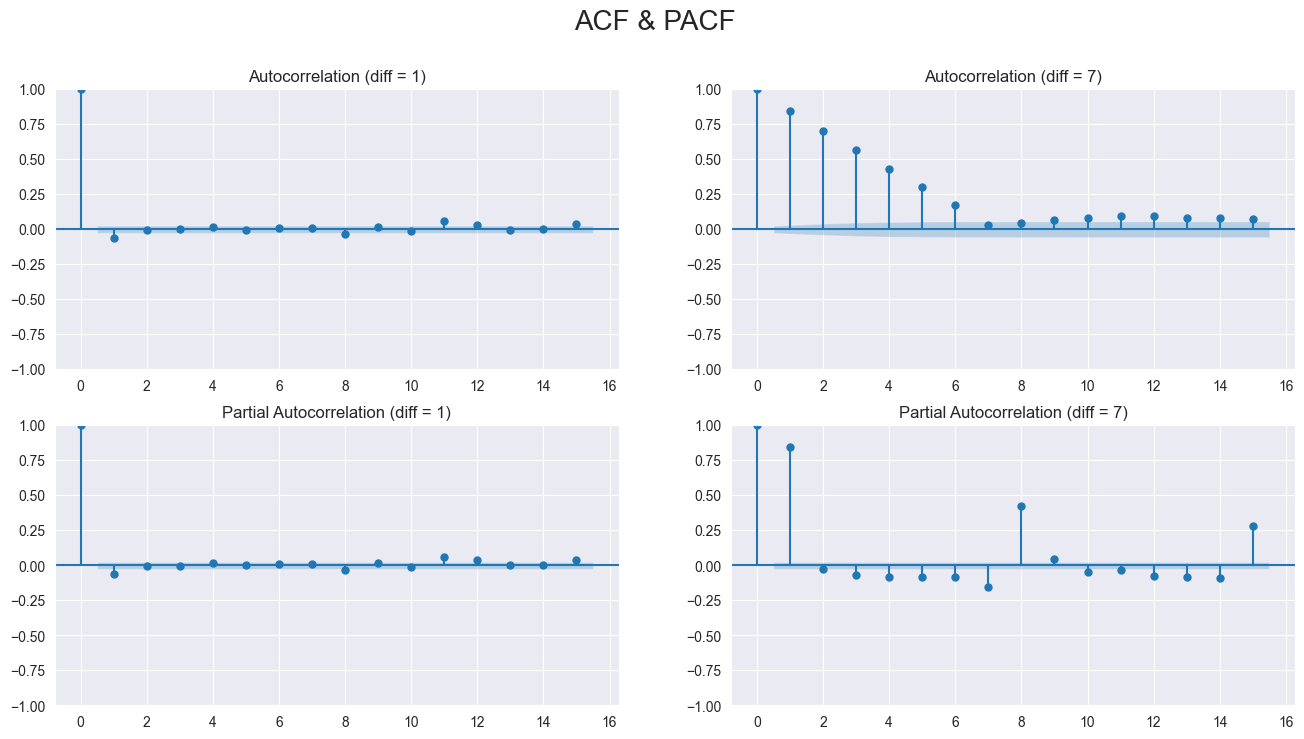

In [82]:
lags = 15

fig, axs = plt.subplots(
    nrows = 2,
    ncols = 2,
    figsize = (16, 8)
)

fig.suptitle(
    'ACF & PACF',
    fontsize = 20)

ax = axs[0, 0]
col_prefix = 'ultimo_diff'
count = 1

plot_acf(
    df[f'{col_prefix}{count}'].iloc[count:],
    lags = lags,
    ax = ax,
    title = f'Autocorrelation (diff = {count})'
)

ax = axs[1, 0]
plot_pacf(
    df[f'{col_prefix}{count}'].iloc[count:],
    lags = lags,
    ax = ax,
    title = f'Partial Autocorrelation (diff = {count})'
)

ax = axs[0, 1]
count = 7

plot_acf(
    df[f'{col_prefix}{count}'].iloc[count:],
    lags = lags,
    ax = ax,
    title = f'Autocorrelation (diff = {count})'
)

ax = axs[1, 1]
plot_pacf(
    df[f'{col_prefix}{count}'].iloc[count:],
    lags = lags,
    ax = ax,
    title = f'Partial Autocorrelation (diff = {count})'
)

A partir dessas observações, para nosso modelo `ARIMA`:

$p = 2$ a partir do gráfico PACF

$d = 1$ diferenciação necessária 

$q = 2$ a partir do gráfico ACF



## Considerando 'regressors'
Existem fatores externos que afetam nossos dados, em particular o choque da pandemia e o efeito de fins de semana e feriados.

In [83]:
df_dummies = pd.merge(
    pd.get_dummies(df['dia_semana']),
    df,
    left_index=True,
    right_index=True
    )
df_dummies = df_dummies.drop('dia_semana', axis=1)
df_dummies.head()

,Friday,Monday,Saturday,Sunday,Thursday,Tuesday,Wednesday,ultimo,dia_util,ultimo_diff1,ultimo_diff7
data,,,,,,,,,,,
2010-01-29,True,False,False,False,False,False,False,65.402,True,NaN,NaN
2010-01-30,False,False,True,False,False,False,False,65.402,False,0.000,NaN
2010-01-31,False,False,False,True,False,False,False,65.402,False,0.000,NaN
2010-02-01,False,True,False,False,False,False,False,66.572,True,1.170,NaN
2010-02-02,False,False,False,False,False,True,False,67.163,True,0.591,NaN


In [84]:
# le = LabelEncoder()
df['mes'] = df.index.month
df['dia_semana'] = df.index.day_of_week
df['dia'] = df.index.day
df.head()

,ultimo,dia_semana,dia_util,ultimo_diff1,ultimo_diff7,mes,dia
data,,,,,,,
2010-01-29,65.402,4,True,NaN,NaN,1,29
2010-01-30,65.402,5,False,0.000,NaN,1,30
2010-01-31,65.402,6,False,0.000,NaN,1,31
2010-02-01,66.572,0,True,1.170,NaN,2,1
2010-02-02,67.163,1,True,0.591,NaN,2,2


### Marcação de anomalias
Marcaremos o ano de 2020 como anômalo, devido à pandemia.

In [85]:
anomaly = ('2019-12-31', '2021-01-01')

mask = (df.index > anomaly[0]) & (df.index < anomaly[1])
df['anomalia'] = False
df.loc[mask, 'anomalia'] = True

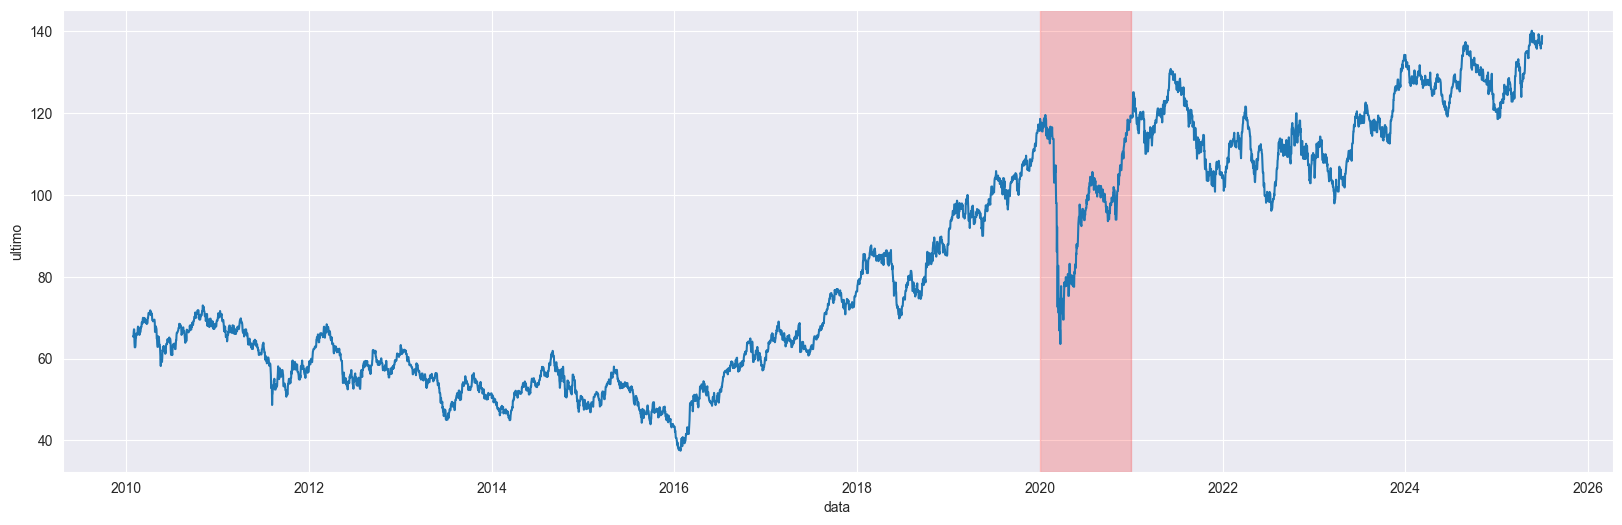

In [86]:
fig = plt.figure(figsize=(20,6))
col = 'ultimo'

sns.lineplot(
    df[col]
);

plt.axvspan(
    xmin = anomaly[0],
    xmax = anomaly[1],
    color = 'r',
    alpha = 0.2
)

### Heatmap

<Axes: >

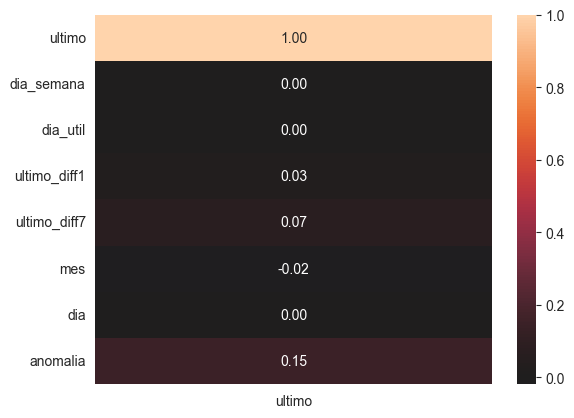

In [87]:
sns.heatmap(
    df.corr()[['ultimo']],
    annot=True,
    center = 0,
    fmt = '.2f'
)

## Separação de dados

In [88]:
target_col = ['ultimo']
train_cols = ['dia_semana','dia_util','ultimo_diff1','ultimo_diff7','mes','dia','anomalia']

### Separação simples

In [89]:
prediction_n = 30
df_train = df.iloc[:-prediction_n]
df_test = df.iloc[-prediction_n:]

print(f'Train\t{len(df_train)}\nTest\t{len(df_test)}')

Train	5602
Test	30


### Separação K-Fold

In [90]:
n_folds = 3
folds = {}

splitter = TimeSeriesSplit(
    n_splits = n_folds
)

for i, (train_index, test_index) in enumerate(splitter.split(df)):
    print(f"Fold {i}:")

    print(f"  Train: index={train_index} ({len(train_index)})")

    print(f"  Test:  index={test_index} ({len(test_index)})")

    folds[i] = (train_index, test_index)


Fold 0:
  Train: index=[   0    1    2 ... 1405 1406 1407] (1408)
  Test:  index=[1408 1409 1410 ... 2813 2814 2815] (1408)
Fold 1:
  Train: index=[   0    1    2 ... 2813 2814 2815] (2816)
  Test:  index=[2816 2817 2818 ... 4221 4222 4223] (1408)
Fold 2:
  Train: index=[   0    1    2 ... 4221 4222 4223] (4224)
  Test:  index=[4224 4225 4226 ... 5629 5630 5631] (1408)


## Modelo baseline

In [91]:
model_predictions = {}

In [92]:
current_model = 'arima_baseline'

model_arima_baseline = ARIMA(
    df_train[target_col],
    order = (1, 1, 0)
).fit()

model_predictions[current_model] = [model_arima_baseline, model_arima_baseline.predict(len(df_train), len(df_train) + prediction_n -1)]

model_arima_baseline.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                 ultimo   No. Observations:                 5602
Model:                 ARIMA(1, 1, 0)   Log Likelihood               -7787.323
Date:                Wed, 16 Jul 2025   AIC                          15578.645
Time:                        17:15:36   BIC                          15591.907
Sample:                    01-29-2010   HQIC                         15583.267
                         - 05-31-2025                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.0641      0.005    -13.202      0.000      -0.074      -0.055
sigma2         0.9444      0.005    173.154      0.000       0.934       0.955
===================================================================================
Ljung-Box (L1) (Q):                   0.00   Jarque-Bera (JB):             90057.09
Prob(Q):                              0.96   Prob(JB):                         0.00
Heteroskedasticity (H):               2.80   Skew:                            -1.19
Prob(H) (two-sided):                  0.00   Kurtosis:                        22.50
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [93]:
model_predictions['arima_baseline'][1].shape

(30,)

In [94]:
mean_squared_error(
    df_test[target_col],
    model_predictions['arima_baseline'][1]
)

0.8532011333333375

In [95]:
def plot_prediction(target, df_train, df_pred, df_test, model_name : str = ''):
    fig = plt.figure(figsize = (16, 6))
    ax = plt.subplot()

    ax.plot(
        df_train[target],
        label = 'Train',
    )

    ax.plot(
        df_pred,
        label = 'Predicted',
        color = 'red'
    )

    ax.plot(
        df_test[target],
        label = 'Expected',
        color = 'green',
        alpha = 0.5
    )
    plt.legend()

    print(f'MSE\t {mean_squared_error(df_test[target], df_pred)}')

MSE	 0.8532011333333375


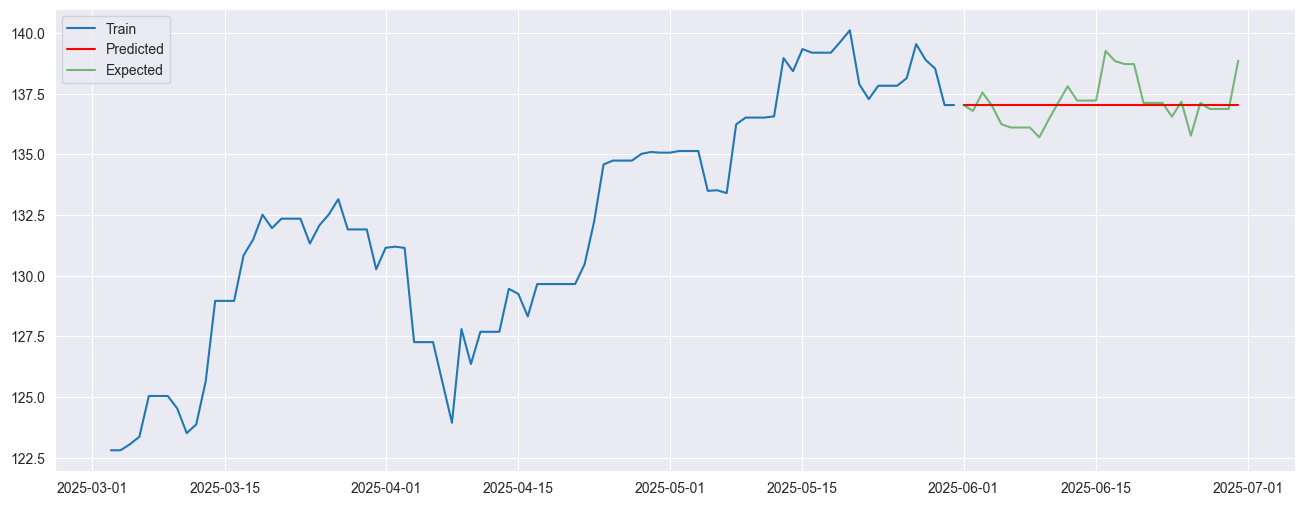

In [96]:
plot_prediction(
    target = target_col,
    df_train = df_train[-prediction_n - prediction_n*2:],
    df_pred = model_predictions[current_model][1],
    df_test = df_test,
    model_name = current_model
)

#### Statistics
AIC = 15578.645

MSE = 0.8532

## ARIMA

### Grid search
Se baseando na ordem acima, vamos procurar o melhor modelo.

In [97]:
def grid_arima(df : pd.DataFrame, pmin : int, pmax : int, dmin : int, dmax : int, qmin : int, qmax : int):
    p = range(pmin, pmax+1)
    d = range(dmin, dmax+1)
    q = range(qmin, qmax+1)

    pqd = list(product(p, d, q))

    aics = []

    for order in pqd:
        # print(f'Testing {order}')
        try:
            model = ARIMA(
                df,
                order = order
            ).fit()
            aics.append((order, model.aic))
        except:
            print(f'Failed {order}, moving on')
            continue
    
    # ordenando por menor AIC
    aics.sort(key = lambda x: x[1])

    return aics

In [ ]:
grid_arima_results = grid_arima(
    df = df_train[target_col],
    pmin = 1,
    pmax = 9,
    dmin = 1,
    dmax = 4,
    qmin = 1,
    qmax = 3
)
grid_arima_results[0]

Failed (1, 1, 3), moving on


d:\_FIAP\02.Challenge 2\venv\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
d:\_FIAP\02.Challenge 2\venv\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
d:\_FIAP\02.Challenge 2\venv\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


In [ ]:
grid_arima_top5 = [result[0] for result in grid_arima_results[:5]]
grid_arima_top5

[(9, 1, 3), (4, 1, 3), (5, 1, 3), (7, 1, 3), (9, 1, 2)]

### Utilizando os resultados

In [ ]:
current_model = 'model_arima_1'

model_arima_1 = ARIMA(
                df_train[target_col],
                order = grid_arima_results[0][0]
            ).fit()


model_predictions[current_model] = (model_arima_1, model_arima_1.predict(
    len(df_train),
    len(df_train) + prediction_n -1
    ))

d:\_FIAP\02.Challenge 2\venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


MSE	 1.0475117201399158


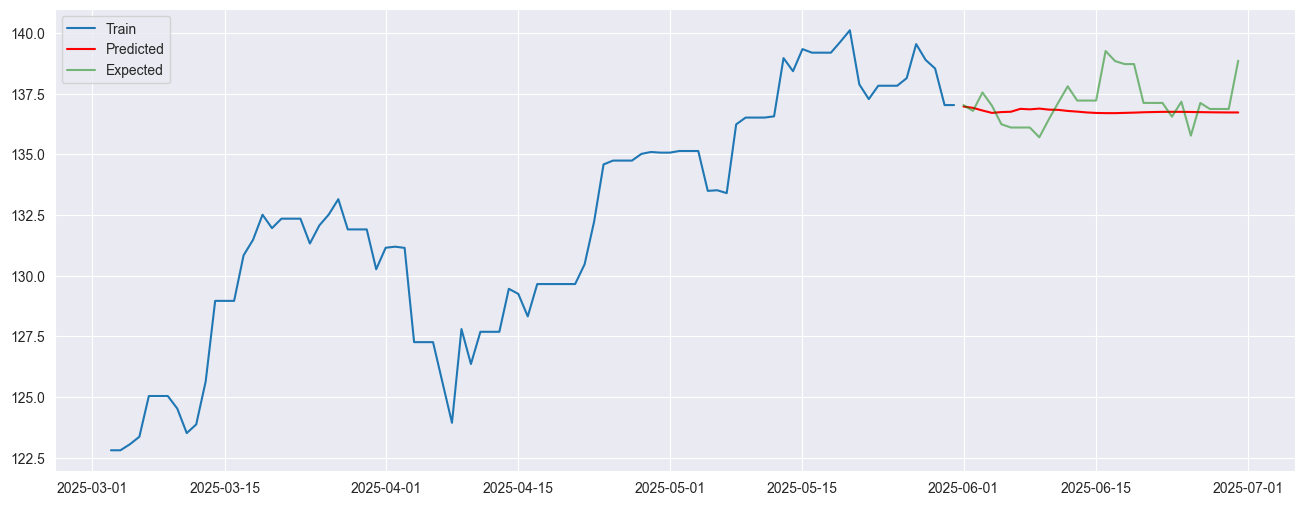

In [ ]:
plot_prediction(
    target = target_col,
    df_train = df_train[-prediction_n - prediction_n*2:],
    df_pred = model_predictions[current_model][1],
    df_test = df_test,
    model_name = current_model
)

## ARIMA 2

In [ ]:
grid_arima_top5

[(9, 1, 3), (4, 1, 3), (5, 1, 3), (7, 1, 3), (9, 1, 2)]

In [ ]:
grid_arima_results_2 = grid_arima(
    df = df_train[target_col],
    pmin = 4,
    pmax = 14,
    dmin = 1,
    dmax = 1,
    qmin = 2,
    qmax = 4
)
grid_arima_results_2[0]

d:\_FIAP\02.Challenge 2\venv\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
d:\_FIAP\02.Challenge 2\venv\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
d:\_FIAP\02.Challenge 2\venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
d:\_FIAP\02.Challenge 2\venv\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
d:\_FIAP\02.Challenge 2

((11, 1, 4), np.float64(15558.092293265916))

In [ ]:
grid_arima_2_top5 = [x[0] for x in grid_arima_results_2[:5]]
grid_arima_2_top5

[(11, 1, 4), (11, 1, 3), (12, 1, 3), (13, 1, 3), (14, 1, 3)]

d:\_FIAP\02.Challenge 2\venv\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
d:\_FIAP\02.Challenge 2\venv\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
d:\_FIAP\02.Challenge 2\venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


MSE	 1.1271862279494291


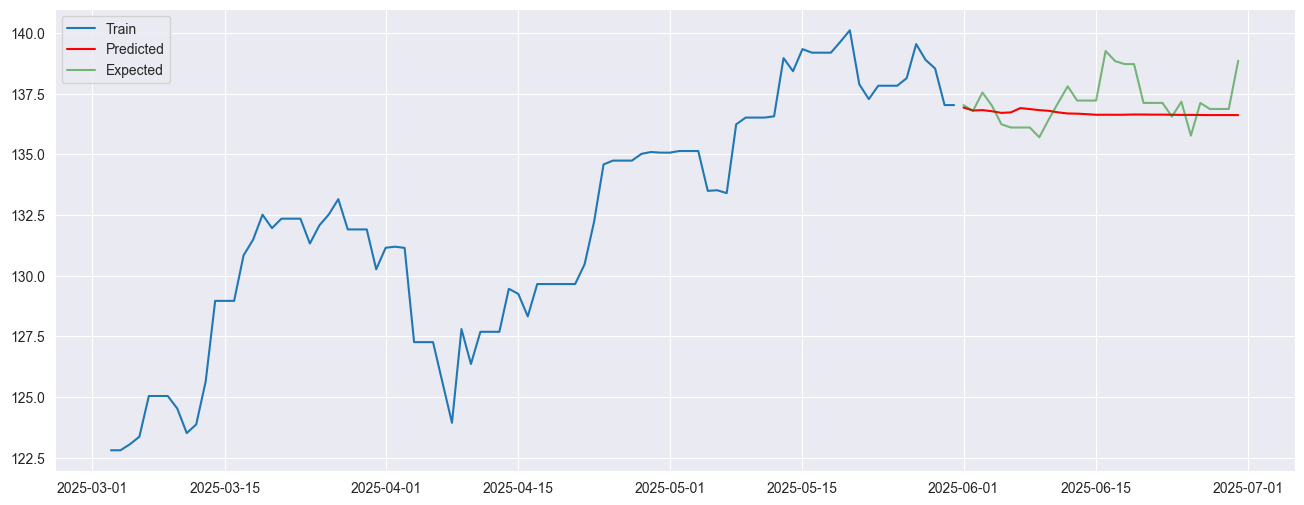

In [ ]:
current_model = 'model_arima_2'

model_arima_2 = ARIMA(
                df_train[target_col],
                order = grid_arima_results_2[0][0]
            ).fit()


model_predictions[current_model] = (model_arima_2, model_arima_2.predict(
    len(df_train),
    len(df_train) + prediction_n -1
    ))

plot_prediction(
    target = target_col,
    df_train = df_train[-prediction_n - prediction_n*2:],
    df_pred = model_predictions[current_model][1],
    df_test = df_test,
    model_name = current_model
)

## ARIMAX
Adicionando nossas variáveis externas

In [ ]:
external_variables = ['anomalia', 'dia_util']

## SARIMA

In [ ]:
def grid_sarima(df : pd.DataFrame, pmin : int, pmax : int, dmin : int, dmax : int, qmin : int, qmax : int):
    p = range(pmin, pmax+1)
    d = range(dmin, dmax+1)
    q = range(qmin, qmax+1)

    pqd = list(product(p, d, q))

    aics = []

    for order in pqd:
        print(f'Testing {order}')
        try:
            model = ARIMA(
                df,
                order = order
            ).fit()
            aics.append((order, model.aic))
        except:
            print(f'Failed, moving on')
            continue
    
    # ordenando por menor AIC
    aics.sort(key = lambda x: x[1])

    return aics

In [ ]:
grid_arima_results = grid_arima(
    df = df_train[target_col],
    pmin = 1,
    pmax = 9,
    dmin = 1,
    dmax = 4,
    qmin = 1,
    qmax = 3
)
grid_arima_results[0]

Para os dados sazonais:

$P = 16$ anos

$D$ = número de diferenciações necessárias, nesse caso $1$

$Q = 2$ a partir do gráfico PACF

$d = 7$ sazonalidade semanal

Vamos utilizar esses valores como base, e testar vários modelos.

***
# 3.

***
# 4.

***
# 5.